<a href="https://colab.research.google.com/github/Shir234/Investment-portfolio-management-system/blob/main/SINGLE_STOCK_WITH_PIPES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_ta
!pip install scikeras
!pip install tensorflow

import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from posixpath import split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from tensorflow.keras.layers import Input

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor


# Pipeline to fetch stock data and feature engineering

In [ ]:
# fetch historical stock data
class DataFetcher(BaseEstimator, TransformerMixin):
    def __init__(self, ticker_symbol, start_date, end_date):
        self.ticker_symbol = ticker_symbol
        self.start_date = start_date
        self.end_date = end_date

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        ticker = yf.Ticker(self.ticker_symbol)
        return ticker.history(start=self.start_date, end=self.end_date)

# add market indicators
class IndicatorCalculator(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.indicators = [
            'psar', 'mfi', 'mvp'
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()
        for indicator in self.indicators:
            try:
                if indicator == 'psar':
                    psar = ta.psar(data['High'], data['Low'], data['Close'])
                    data['PSAR'] = psar['PSARl_0.02_0.2']
                elif indicator == 'mfi':
                    data['MFI'] = ta.mfi(data['High'], data['Low'], data['Close'], data['Volume']).astype(float)
                # Add other indicators as needed
                ################## ADD MVP HERE
                # Calculate Moving Volatility Pattern (MVP)
                # Here we're assuming MVP as a simple moving average of squared returns
                elif indicator == 'mvp':
                  data['Returns'] = data['Close'].pct_change()                                                          # calculate the daily return
                  data['Volatility'] = data['Returns'].rolling(window=28).std() * np.sqrt(252)                          # calculate 28-day rolling volatility (daily annual volatility)
                  data['MVP'] = data['Volatility'].pct_change()                                                         # the pct change of the volatility, Rate of change of volatility
                  threshold = 0.01
                  data['MVP_Signal'] = np.where(abs(data['MVP']) < threshold, 0)                                        # buy when the abs mvp is almost 0
            except Exception as e:
                print(f"Error adding indicator {indicator}: {e}")
        return data

# calculate buy and sell signals based on psar indicator
class SignalCalculator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()
        data['Signal'] = np.where(data['Close'] > data['PSAR'], 1, 0)
        data['Signal_Shift'] = data['Signal'].shift(1)
        data['Buy'] = np.where((data['Signal'] == 1) & (data['Signal_Shift'] == 0), data['Close'], np.nan)
        data['Sell'] = np.where((data['Signal'] == 0) & (data['Signal_Shift'] == 1), data['Close'], np.nan)
        return data

# for each transaction calculate: volatility, return and sharpe ratio
class TransactionMetricsCalculator(BaseEstimator, TransformerMixin):
    def __init__(self, risk_free_rate=0.02):
        self.risk_free_rate = risk_free_rate

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()
        volatility_list = []
        returns_list = []
        sharpe_ratio_list = []
        duration_list = []
        last_buy_index = None
        last_buy_price = None

        for i in range(len(data)):
            if not np.isnan(data['Buy'].iloc[i]):
                last_buy_index = i
                last_buy_price = data['Close'].iloc[i]

            if not np.isnan(data['Sell'].iloc[i]) and last_buy_index is not None:
                sell_date = data.index[i]
                buy_date = data.index[last_buy_index]
                duration = (sell_date - buy_date).days

                # Calculate raw return for this transaction
                returns = (data['Close'].iloc[i] - last_buy_price) / last_buy_price

                ###volatility = data['Close'].iloc[last_buy_index:i+1].std()
                # Calculate volatility (standard deviation of daily returns) for this transaction
                daily_returns = data['Close'].iloc[last_buy_index:i+1].pct_change().dropna()
                volatility = daily_returns.std()

                # Calculate Sharpe ratio for this transaction
                # Assuming risk_free_rate is annual, we'll adjust it for the transaction duration
                transaction_risk_free_rate = self.risk_free_rate * (duration / 365)
                sharpe_ratio = (returns - transaction_risk_free_rate) / volatility if volatility != 0 else 0                        # all in the same scale: returns is the return ratio, the vplatility is pct


                volatility_list.append(volatility)
                returns_list.append(returns)
                sharpe_ratio_list.append(sharpe_ratio)
                duration_list.append(duration)

                last_buy_index = None
                last_buy_price = None


        data['Transaction_Volatility'] = pd.Series(volatility_list, index=data.index[data['Sell'].notna()])
        data['Transaction_Returns'] = pd.Series(returns_list, index=data.index[data['Sell'].notna()])
        data['Transaction_Sharpe'] = pd.Series(sharpe_ratio_list, index=data.index[data['Sell'].notna()])
        # transaction duration in days
        data['Transaction_Duration'] = pd.Series(duration_list, index=data.index[data['Sell'].notna()])

        return data

def create_enhanced_stock_data_pipeline(ticker_symbol, start_date, end_date, risk_free_rate):
    return Pipeline([
        ('data_fetcher', DataFetcher(ticker_symbol, start_date, end_date)),
        ('indicator_calculator', IndicatorCalculator()),
        ('signal_calculator', SignalCalculator()),
        ('transaction_metrics_calculator', TransactionMetricsCalculator(risk_free_rate)),
    ])


## Use the pipeline - Tesla stock as an example


In [ ]:
# USE THE PIPELINE
ticker_symbol = "TSLA"
start_date = "2020-01-01"
end_date = "2024-01-01"
risk_free_rate = 0.02  # 2% annual risk-free rate, you can adjust this value

pipeline = create_enhanced_stock_data_pipeline(ticker_symbol, start_date, end_date, risk_free_rate)
data = pipeline.fit_transform(pd.DataFrame())

data.to_csv(f'{ticker_symbol}_processed_data.csv')
print(data.info())

Error adding indicator mvp: either both or neither of x and y should be given
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 00:00:00-05:00 to 2023-12-29 00:00:00-05:00
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    1006 non-null   float64
 1   High                    1006 non-null   float64
 2   Low                     1006 non-null   float64
 3   Close                   1006 non-null   float64
 4   Volume                  1006 non-null   int64  
 5   Dividends               1006 non-null   float64
 6   Stock Splits            1006 non-null   float64
 7   PSAR                    580 non-null    float64
 8   MFI                     993 non-null    float64
 9   Returns                 1005 non-null   float64
 10  Volatility              978 non-null    float64
 11  MVP                     977 non-null    float64
 12  Signal              

<ipython-input-29-af472cf2b77b>:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.90509154e+09 4.53654405e+09 8.30951382e+09 1.51450579e+10
 1.36343773e+10 1.55635166e+10 6.94779693e+09 9.63875537e+09
 1.80179355e+10 6.68718361e+09 1.03143077e+10 1.84639652e+10
 1.01446598e+10 3.51365323e+10 5.46403688e+10 1.27852256e+10
 1.92877792e+10 9.29904332e+09 2.06546264e+10 1.25471136e+10
 1.39285947e+10 2.34164471e+10 1.28571238e+10 1.46345090e+10
 1.94978610e+10 9.98732939e+09 1.24616827e+10 1.25429221e+10
 1.13918120e+10 1.13708397e+10 9.26463837e+09 1.10094777e+10
 7.62574790e+09 9.81282305e+09 7.75906956e+09 1.41106556e+10
 2.18540438e+10 1.72344728e+10 1.52274891e+10 9.96211600e+09
 1.01747012e+10 9.48648025e+09 1.60848897e+10 1.29018278e+10
 2.29217775e+10 1.42430844e+10 1.31929790e+10 8.65195855e+09
 9.02538230e+09 1.30323708e+10 1.30473698e+10 8.38235838e+09
 9.53574149e+09 5.97744800e+09 1.00328409e

# correlation matrix

In [ ]:
def visualize_correlation_matrix(df,ticker_symbol, show_values=False):
    # Convert the date column to datetime if it exists
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])

    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    # Calculate the correlation matrix
    correlation_matrix = numeric_df.corr()



    # Create the heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix,
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                center=0,
                square=True,
                linewidths=.5,
                cbar_kws={"shrink": .5}
                )

    plt.title(f'{ticker_symbol} Correlation Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Optionally print the numerical values of the correlation matrix
    if show_values:
        print(f"Correlation Matrix for {ticker_symbol}:")
        print(correlation_matrix)

# Usage:
# visualize_correlation_matrix("TSLA", show_values=True)

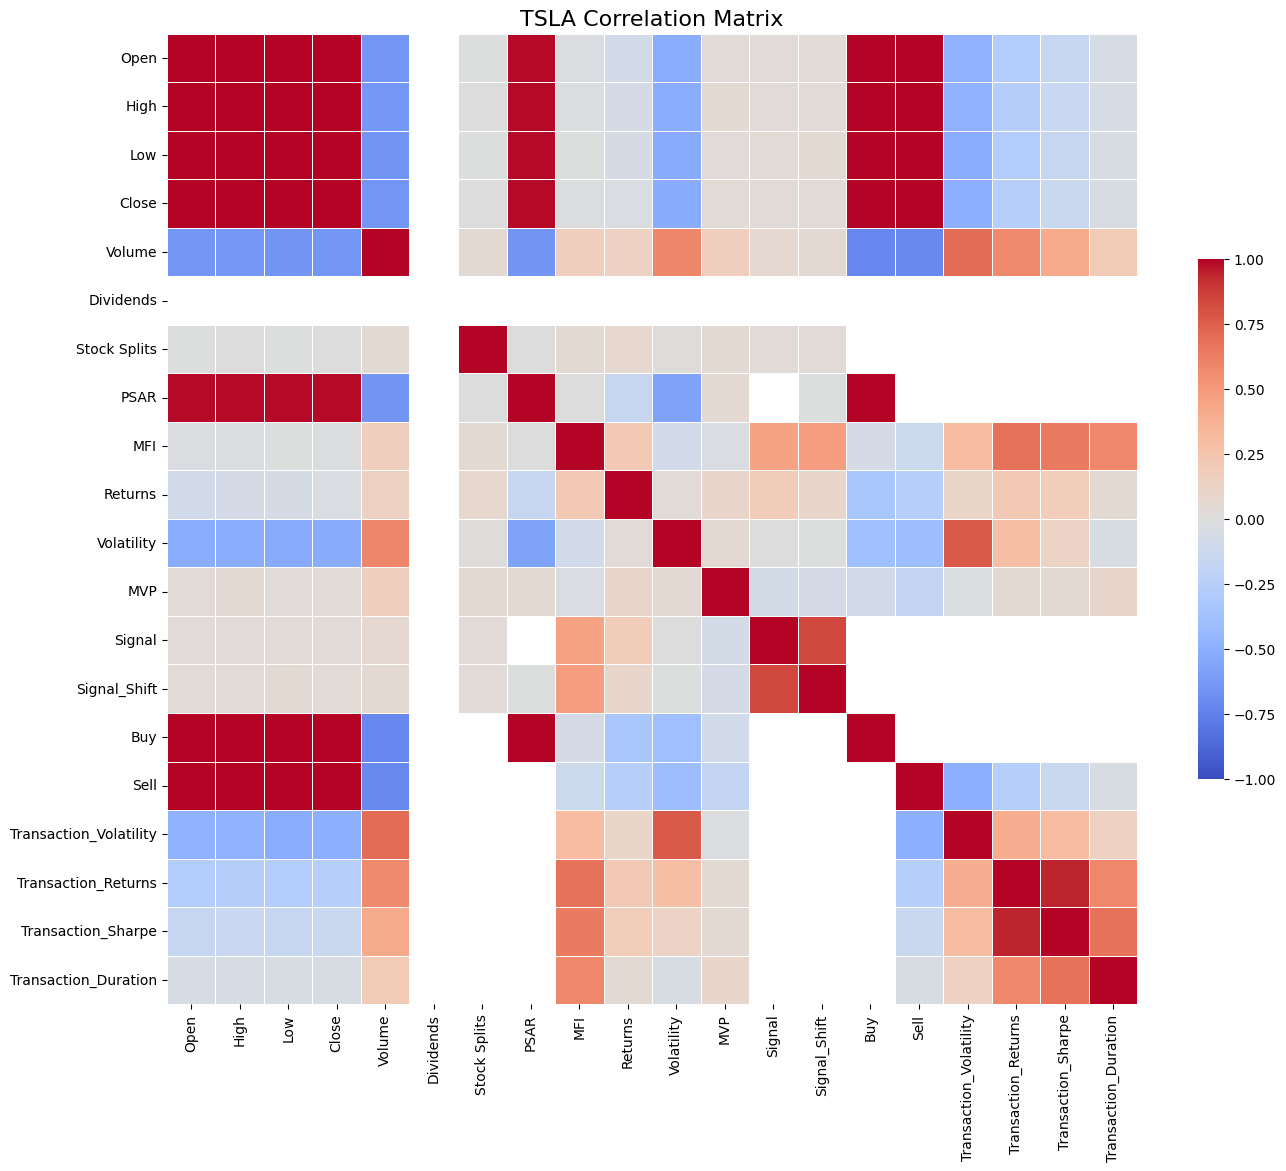

Correlation Matrix for TSLA:
                            Open      High       Low     Close    Volume  \
Open                    1.000000  0.998735  0.998240  0.996345 -0.642844   
High                    0.998735  1.000000  0.998282  0.998355 -0.633413   
Low                     0.998240  0.998282  1.000000  0.998537 -0.652380   
Close                   0.996345  0.998355  0.998537  1.000000 -0.640960   
Volume                 -0.642844 -0.633413 -0.652380 -0.640960  1.000000   
Dividends                    NaN       NaN       NaN       NaN       NaN   
Stock Splits           -0.001606  0.001905 -0.001562  0.002886  0.053126   
PSAR                    0.990930  0.989591  0.991503  0.989525 -0.653612   
MFI                    -0.019924 -0.017867 -0.006910 -0.008269  0.164673   
Returns                -0.088530 -0.062574 -0.058341 -0.029182  0.142918   
Volatility             -0.515499 -0.508578 -0.526313 -0.517690  0.588765   
MVP                     0.035096  0.049141  0.027610  0.039

In [ ]:
visualize_correlation_matrix(data,ticker_symbol, show_values=True)

# Stocks Splits Graph before cleaning the data

In [ ]:
# # Analysis for 'Stock Splits'
# data['Stock Splits'] = data['Stock Splits'].replace(0, 1)  # Assuming no split is equivalent to 1:1 split

# # Plot 1: Time Series of Stock Splits
# plt.figure(figsize=(12, 6))
# plt.plot(data.index, data['Stock Splits'], marker='o', linestyle='-', linewidth=1, markersize=4)
# plt.title('Stock Splits Over Time')
# plt.xlabel('Date')
# plt.ylabel('Stock Split Ratio')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Plot 2: Close Price vs Stock Splits
# plt.figure(figsize=(12, 6))
# plt.scatter(data.index, data['Close'], c=data['Stock Splits'], cmap='viridis', alpha=0.6)
# plt.colorbar(label='Stock Split Ratio')
# plt.title('Close Price with Color Indicating Stock Splits')
# plt.xlabel('Date')
# plt.ylabel('Close Price')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Plot 3: Scatter Plot of Close Price Before and After Stock Splits
# # This plot requires adjusting the data to show price before and after splits
# data['Close_Adjusted'] = data['Close'] * data['Stock Splits'].cumprod()
# plt.figure(figsize=(10, 6))
# plt.scatter(data['Close'].shift(1), data['Close'], c=data['Stock Splits'], cmap='viridis')
# plt.colorbar(label='Stock Split Ratio')
# plt.xlabel('Close Price Before Split')
# plt.ylabel('Close Price After Split')
# plt.title('Impact of Stock Splits on Close Price')
# plt.plot([data['Close'].min(), data['Close'].max()], [data['Close'].min(), data['Close'].max()], 'r--', lw=2)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Plot 4: Correlation Heatmap
# corr = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
# plt.title('Correlation Heatmap')
# plt.tight_layout()
# plt.show()

# # Plot 5: Box Plot to show distribution of Close Price by Stock Split Ratio
# plt.figure(figsize=(12, 6))
# sns.boxplot(data=data, x='Stock Splits', y='Close')
# plt.title('Distribution of Close Price by Stock Split Ratio')
# plt.xlabel('Stock Split Ratio')
# plt.ylabel('Close Price')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [ ]:
# #Analysis for Sharpe

# # 1. Time Series of Sharpe Ratio
# plt.figure(figsize=(12, 6))
# plt.plot(data.index, data['Transaction_Sharpe'], marker='o', linestyle='-', linewidth=1, markersize=4, alpha=0.7)
# plt.title('Sharpe Ratio Over Time')
# plt.xlabel('Date')
# plt.ylabel('Sharpe Ratio')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 2. Distribution of Sharpe Ratio
# plt.figure(figsize=(10, 6))
# sns.histplot(data['Transaction_Sharpe'].dropna(), kde=True)
# plt.title('Distribution of Sharpe Ratio')
# plt.xlabel('Sharpe Ratio')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 3. Boxplot of Sharpe Ratio by Year
# data['Year'] = data.index.year
# plt.figure(figsize=(12, 6))
# sns.boxplot(data=data, x='Year', y='Transaction_Sharpe', whis=[0, 100])
# plt.title('Sharpe Ratio Distribution by Year')
# plt.xlabel('Year')
# plt.ylabel('Sharpe Ratio')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 4. Scatter Plot of Sharpe Ratio vs Return
# plt.figure(figsize=(10, 6))
# plt.scatter(data['Transaction_Returns'], data['Transaction_Sharpe'], alpha=0.6)
# plt.title('Sharpe Ratio vs. Transaction Returns')
# plt.xlabel('Transaction Returns')
# plt.ylabel('Sharpe Ratio')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 5. Rolling Sharpe Ratio
# data['Rolling_Sharpe'] = data['Transaction_Sharpe'].rolling(window=20).mean()
# plt.figure(figsize=(12, 6))
# plt.plot(data.index, data['Rolling_Sharpe'], label='Rolling Sharpe Ratio')
# plt.title('Rolling Sharpe Ratio (Window=20)')
# plt.xlabel('Date')
# plt.ylabel('Rolling Sharpe Ratio')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 6. Sharpe Ratio vs Volatility (using Transaction_Volatility if available)
# if 'Transaction_Volatility' in data.columns:
#     plt.figure(figsize=(10, 6))
#     plt.scatter(data['Transaction_Volatility'], data['Transaction_Sharpe'], alpha=0.5)
#     plt.title('Sharpe Ratio vs. Transaction Volatility')
#     plt.xlabel('Transaction Volatility')
#     plt.ylabel('Sharpe Ratio')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Transaction_Volatility not available in the dataset.")

# # 7. Correlation Heatmap including Sharpe Ratio
# # Assuming you have other features related to your analysis
# features_for_corr = ['Transaction_Sharpe', 'Transaction_Returns', 'Transaction_Volatility', 'Close', 'Volume', 'PSAR']  # Add more as needed
# corr = data[features_for_corr].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
# plt.title('Correlation Heatmap with Sharpe Ratio')
# plt.tight_layout()
# plt.show()

# Pineline to clean the data, remove outliers, and handle correlation

In [ ]:
# use forward fill then backward filll (normal in financial data) on all continues columns
class MissingValueHandler(BaseEstimator, TransformerMixin):
  def __init__(self, fill_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'PSAR', 'MFI', 'MVP']):
    self.fill_columns = fill_columns

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X_ = X.copy()
    for col in self.fill_columns:
      if col in X_.columns:
        X_[col] = X_[col].fillna(method='ffill').fillna(method='bfill')

    # if 'Signal_Shift' in X_.columns:
    #   X_['Signal_Shift']= X_['Signal_Shift'].fillna(-1)
    for col in X_.columns:
      X_[col] = X_[col].fillna(-1)

    return X_


# handle outliers: Use Z-score to identify data points that deviate significantly from the mean - rolling eondow of 28 days
class OutlierHandler(BaseEstimator, TransformerMixin):
  def __init__(self,threshold=3, window=28):
    self.threshold = threshold
    self.window = window

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X_ = X.copy()
    X_ = X_.dropna(axis =1, how = 'all')
    for column in X_.columns:
      if X_[column].dtype in ['float64', 'int64']:
        rolling_mean = X_[column].rolling(window=self.window).mean()
        rolling_std = X_[column].rolling(window=self.window).std()
        z_scores = np.abs((X_[column] - rolling_mean) / rolling_std)
        X_[column] = X_[column].mask(z_scores > self.threshold, rolling_mean)
        # z_scores = np.abs((X_[column] - X_[column].mean()) / X_[column].std())
        # X_[column] = X_[column].mask(z_scores > self.threshold, X_[column].mean())

    return X_

class CorrelationHandler(BaseEstimator, TransformerMixin):
  def __init__(self, threshold=0.95):
    self.threshold = threshold
    self.columns_to_drop = None

  def fit(self, X, y=None):
    # handle high correlation of continues columns
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    self.columns_to_drop = [col for col in upper.columns if any(upper[col] > self.threshold)]

    # check all columns correlation with the target variable, if nan - remove (doesnt help for prediction later)
    if 'Transaction_Sharpe' in X.columns:
      target_corr = X.corr()['Transaction_Sharpe']
      nan_corr_columns = target_corr[target_corr.isna()].index.tolist()
      self.columns_to_drop.extend(nan_corr_columns)

    if 'Transaction_Sharpe' in self.columns_to_drop:
      self.columns_to_drop.remove('Transaction_Sharpe')

    return self

  def transform(self, X):
    X_ = X.copy()
    for col in self.columns_to_drop:
      if col in X_.columns:
        print(f"Dropping column {col} due to NaN correlation with target")
    return X_.drop(self.columns_to_drop, axis=1, errors='ignore')


def create_data_cleaning_pipeline(correlation_threshold = 0.95):
  return Pipeline([
      ('missing_value_handler', MissingValueHandler()),
      ('outlier_handler', OutlierHandler()),
      ('correlation_handler', CorrelationHandler(correlation_threshold))
  ])

## Use the pipeline - Tesla stock clean data as an example


In [ ]:
# USE THE PIPELINE

pipeline_clean = create_data_cleaning_pipeline()
data_clean = pipeline_clean.fit_transform(data)

data_clean.to_csv(f'{ticker_symbol}_clean_data.csv')
print(data_clean.info())

Dropping column High due to NaN correlation with target
Dropping column Low due to NaN correlation with target
Dropping column Close due to NaN correlation with target
Dropping column PSAR due to NaN correlation with target
Dropping column Dividends due to NaN correlation with target
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 00:00:00-05:00 to 2023-12-29 00:00:00-05:00
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    1006 non-null   float64
 1   Volume                  1006 non-null   float64
 2   Stock Splits            1006 non-null   float64
 3   MFI                     1006 non-null   float64
 4   Returns                 1006 non-null   float64
 5   Volatility              1006 non-null   float64
 6   MVP                     1006 non-null   float64
 7   Signal                  1006 non-null   float64
 8   Signal_Shift            1

<ipython-input-35-ff2d21a5afaa>:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_[col] = X_[col].fillna(method='ffill').fillna(method='bfill')


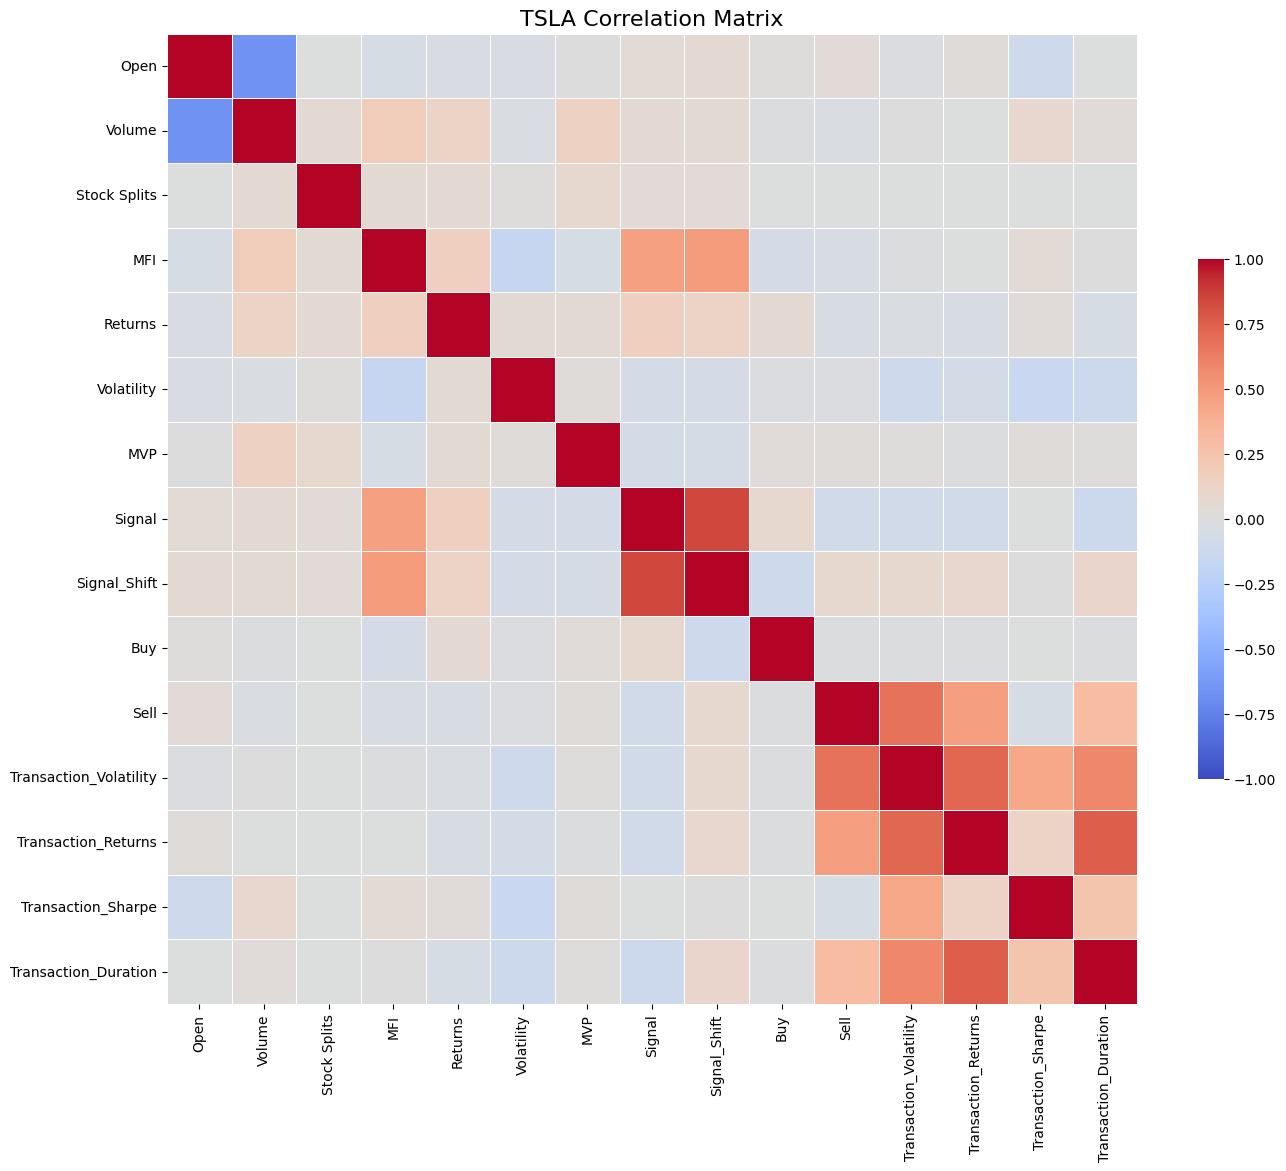

Correlation Matrix for TSLA:
                            Open    Volume  Stock Splits       MFI   Returns  \
Open                    1.000000 -0.666479     -0.001543 -0.053114 -0.035292   
Volume                 -0.666479  1.000000      0.056089  0.173485  0.117535   
Stock Splits           -0.001543  0.056089      1.000000  0.048323  0.062386   
MFI                    -0.053114  0.173485      0.048323  1.000000  0.162547   
Returns                -0.035292  0.117535      0.062386  0.162547  1.000000   
Volatility             -0.038701 -0.026083      0.014757 -0.159838  0.051007   
MVP                     0.003068  0.143259      0.071164 -0.048460  0.054036   
Signal                  0.040463  0.056586      0.036261  0.468740  0.161047   
Signal_Shift            0.058163  0.049856      0.036261  0.490229  0.126021   
Buy                     0.013061 -0.012985     -0.004032 -0.062967  0.061075   
Sell                    0.034587 -0.030876     -0.003784 -0.046091 -0.045096   
Transaction

In [ ]:
visualize_correlation_matrix(data_clean,ticker_symbol, show_values=True)

# Correlation visualization: features and target variable

In [ ]:
def create_correlation_visualizations(data, target_column='Transaction_Sharpe'):
    # Calculate correlations
    correlations = data.corr()

    # 1. Correlation between features (emphasizing low correlation)
    feature_correlations = correlations.drop(target_column).drop(target_column, axis=1)

    # Create a triu mask for the feature correlations
    mask = np.triu(np.ones_like(feature_correlations, dtype=bool))
    tri_feature_correlations = feature_correlations.mask(mask)

    # Melt the dataframe for easier plotting
    melted_correlations = tri_feature_correlations.reset_index().melt(id_vars='index')
    melted_correlations = melted_correlations.dropna()

    plt.figure(figsize=(12, 6))
    sns.stripplot(x='index', y='value', data=melted_correlations, jitter=True, alpha=0.6)
    plt.title('Feature Correlations (Emphasizing Low Correlation)')
    plt.xlabel('Features')
    plt.ylabel('Correlation Coefficient')
    plt.xticks(rotation=90)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

    # 2. Correlation between features and target (emphasizing high correlation)
    target_correlations = correlations[target_column].drop(target_column).sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=target_correlations.index, y=target_correlations.values)
    plt.title(f'Feature Correlations with {target_column}')
    plt.xlabel('Features')
    plt.ylabel('Correlation Coefficient')
    plt.xticks(rotation=90)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

# Usage
# Assuming 'data' is your DataFrame
# create_correlation_visualizations(data)

In [ ]:
#create_correlation_visualizations(data_clean)

# Graph after cleaning the data

In [ ]:
# #Analysis for Sharpe

# # 1. Time Series of Sharpe Ratio
# plt.figure(figsize=(12, 6))
# plt.plot(data_clean.index, data_clean['Transaction_Sharpe'], marker='o', linestyle='-', linewidth=1, markersize=4, alpha=0.7)
# plt.title('Sharpe Ratio Over Time')
# plt.xlabel('Date')
# plt.ylabel('Sharpe Ratio')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 2. Distribution of Sharpe Ratio
# plt.figure(figsize=(10, 6))
# sns.histplot(data_clean['Transaction_Sharpe'].dropna(), kde=True)
# plt.title('Distribution of Sharpe Ratio')
# plt.xlabel('Sharpe Ratio')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 3. Boxplot of Sharpe Ratio by Year
# data_clean['Year'] = data_clean.index.year
# plt.figure(figsize=(12, 6))
# sns.boxplot(data=data_clean, x='Year', y='Transaction_Sharpe', whis=[0, 100])
# plt.title('Sharpe Ratio Distribution by Year')
# plt.xlabel('Year')
# plt.ylabel('Sharpe Ratio')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 4. Scatter Plot of Sharpe Ratio vs Return
# plt.figure(figsize=(10, 6))
# plt.scatter(data_clean['Transaction_Returns'], data_clean['Transaction_Sharpe'], alpha=0.6)
# plt.title('Sharpe Ratio vs. Transaction Returns')
# plt.xlabel('Transaction Returns')
# plt.ylabel('Sharpe Ratio')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 5. Rolling Sharpe Ratio
# data_clean['Rolling_Sharpe'] = data_clean['Transaction_Sharpe'].rolling(window=20).mean()
# plt.figure(figsize=(12, 6))
# plt.plot(data_clean.index, data_clean['Rolling_Sharpe'], label='Rolling Sharpe Ratio')
# plt.title('Rolling Sharpe Ratio (Window=20)')
# plt.xlabel('Date')
# plt.ylabel('Rolling Sharpe Ratio')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # 6. Sharpe Ratio vs Volatility (using Transaction_Volatility if available)
# if 'Transaction_Volatility' in data_clean.columns:
#     plt.figure(figsize=(10, 6))
#     plt.scatter(data_clean['Transaction_Volatility'], data_clean['Transaction_Sharpe'], alpha=0.5)
#     plt.title('Sharpe Ratio vs. Transaction Volatility')
#     plt.xlabel('Transaction Volatility')
#     plt.ylabel('Sharpe Ratio')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Transaction_Volatility not available in the dataset.")

# # 7. Correlation Heatmap including Sharpe Ratio
# # Assuming you have other features related to your analysis
# features_for_corr = ['Transaction_Sharpe', 'Transaction_Returns', 'Transaction_Volatility', 'Volume']  # Add more as needed
# corr = data_clean[features_for_corr].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
# plt.title('Correlation Heatmap with Sharpe Ratio')
# plt.tight_layout()
# plt.show()

# Functions to: Create models, prepare the data for LSTM

In [ ]:
# Create LSTM model
def create_lstm_model(input_shape=(1, 1)):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(), loss='mse')
    return model


def prepare_lstm_data(X, time_steps=1, features=None):
    """
    Prepare data for LSTM by reshaping it to fit the expected 3D shape.

    Parameters:
    - X: Input data, can be 1D, 2D, or already 3D.
    - time_steps: Number of time steps in the sequence. Default is 1 for non-time series data.
    - features: Number of features per time step. If None, it will be inferred from the data.

    Returns:
    - Reshaped data with shape (samples, time_steps, features)
    """
    if len(X.shape) == 1:
        if features is None:
            features = 1  # Assuming single feature if not specified
        X = X.reshape(-1, time_steps, features)
    elif len(X.shape) == 2:
        samples, cols = X.shape
        if features is None:
            features = cols  # All columns are considered as features if not specified
        if cols % time_steps != 0:
            raise ValueError(f"Number of columns ({cols}) must be evenly divisible by time_steps ({time_steps})")
        X = X.reshape(samples, cols // features, features)
    else:
        raise ValueError(f"Input data must be 1D or 2D. Got {len(X.shape)}D data.")

    return X

# Six models we took from stage 1 of the article, each model with list af params to do grid search on (optimize)
"""
Support Vector Regression (SVR)
eXtreme Gradient Boosting (XGBoost)
Light Gradient Boosting Machine (LightGBM)
Random Forest regression (RF)
Gradient Boosting Regression (GBR)
Long Short Term Memory model (LSTM)
"""

def create_models():
  models = {
      'SVR': (SVR(), {
            'kernel': ['rbf', 'linear'],
            'C': [0.1, 1, 10],
            'epsilon': [0.01, 0.1]
        }),
      'XGBoost': (XGBRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
      }),
      'LightGBM': (LGBMRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1],
            'force_row_wise': [True]
      }),
      'RandomForest': (RandomForestRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10]
      }),
      'GradientBoosting': (GradientBoostingRegressor(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
      }),
      'LSTM': (KerasRegressor(model=create_lstm_model, epochs=50, batch_size=32, verbose=0), {
          'model__input_shape': [(1, 1), (None, 1)],
          'epochs': [50, 100],
          'batch_size': [32, 64]
      })
    }
  return models

# Function to:
## Create models, split the data to train and validation for each fold
## train and validate on each fold, save the results

In [ ]:
# Create all models, split the data - 5 folds, choose best params then train and vlidate each model, save performance results and params
def train_and_validate_models(X_train_val, Y_train_val):
  scaler = StandardScaler()                                                      # Add scaling, the features are scaled to have zero mean and unit variance
  X_train_val_scaled = scaler.fit_transform(X_train_val)

  tscv = TimeSeriesSplit(n_splits=5)                                              # time series cross-validation with 5 folds, to ensure temporal order (sequence of events in time)
  models = create_models()
  results = {}

  for model_name, (model, params_grid) in models.items():                         # iterate each model
    print(f"Training {model_name}")

    # reshape the data for LSTM model
    if model_name == 'LSTM':
      features_count = X_train_val_scaled.shape[1]
      X_train_val_scaled = prepare_lstm_data(X_train_val_scaled, time_steps=1, features=features_count)
      params_grid['model__input_shape'] = [(1, features_count), (None, features_count)]

    # Add timeout or max iterations for SVR
    if model_name == 'SVR':
      model.set_params(max_iter=1000)  # Limit iterations

    best_mse_scores = []                                                               # lists to store scores and parameters for the models
    best_rmse_scores = []
    best_params = []
    best_score = float('inf')
    best_model = None
    best_model_prediction = None
    Y_val_best = None

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val_scaled)):  # each fold: split the scaled data to train and val (using the tcsv indices)
      print(f"\nTraining on fold {fold + 1} for {model_name}...")
      # Split the data
      X_train, X_val = X_train_val_scaled[train_idx], X_train_val_scaled[val_idx]
      Y_train, Y_val = Y_train_val.iloc[train_idx], Y_train_val.iloc[val_idx]


      # Find the best params for the current model
      print(f"Performing GridSearchCV for {model_name} on fold {fold + 1}...")

      # Reduce the number of CV splits for SVR to speed up
      cv_splits = 2 if model_name == 'SVR' else 3

      grid_search = GridSearchCV(estimator=model, param_grid=params_grid, scoring='neg_mean_squared_error', cv=cv_splits, n_jobs=-1, verbose=1) # performs search over set of parameters

      try:
        grid_search.fit(X_train, Y_train)                                         # train the model for every combination of parameters on each training set of the fold
        print(f"Best parameters found for fold {fold + 1}: {grid_search.best_params_}")

        # Save the best params
        best_params.append(grid_search.best_params_)

        # Train the best model
        best_model_fold = grid_search.best_estimator_                             # the model that performs the best on the last search

        # Validate using the model
        print("Starting validation: ")
        Y_pred = best_model_fold.predict(X_val)                                   # use the best model after traind and validate

        # Calculate performance for this fold
        mse = mean_squared_error(Y_val, Y_pred)
        rmse = root_mean_squared_error(Y_val, Y_pred)

        # Save
        best_mse_scores.append(mse)
        best_rmse_scores.append(rmse)

        print(f"End of Fold {fold + 1} - MSE: {mse:.4f}, RMSE: {rmse:.4f}")

        # Update best model if this fold's model is better
        if mse < best_score:
          best_score = mse
          best_model = best_model_fold
          best_model_prediction = Y_pred
          Y_val_best= Y_val


      except Exception as e:
                print(f"Error in {model_name} training: {e}")
                continue

    results[model_name] = {                                                       # save the best model for each model type, the results and the parameters
        'best_mse_scores': best_mse_scores,
        'best_rmse_scores': best_rmse_scores,
        'best_params': best_params,
        'best_model': best_model,
        'best_model_prediction': best_model_prediction,
        'Y_val_best' : Y_val_best
    }

  return results

In [ ]:
print("X_train_val shape:", X_train_val.shape)
print("Y_train_val shape:", Y_train_val.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train_val shape: (804, 14)
Y_train_val shape: (804,)
X_test shape: (202, 14)
Y_test shape: (202,)


In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 00:00:00-05:00 to 2023-12-29 00:00:00-05:00
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    1006 non-null   float64
 1   Volume                  1006 non-null   float64
 2   Stock Splits            1006 non-null   float64
 3   MFI                     1006 non-null   float64
 4   Returns                 1006 non-null   float64
 5   Volatility              1006 non-null   float64
 6   MVP                     1006 non-null   float64
 7   Signal                  1006 non-null   float64
 8   Signal_Shift            1006 non-null   float64
 9   Buy                     1006 non-null   float64
 10  Sell                    1006 non-null   float64
 11  Transaction_Volatility  1006 non-null   float64
 12  Transaction_Returns     1006 non-null   float64
 13  Transaction_Sharpe      1006 non-null   float

In [ ]:
max(data_clean['Transaction_Sharpe'])

6.889491188710282

In [ ]:
min(data_clean['Transaction_Sharpe'])

-4.669139545744088

# Split the data to train and test
## call a function to create models, train it then try to predict sharpe based on the features and buying dates
## save results

In [ ]:
print(f"Data_clean shape before splitting: {data_clean.shape}")

Data_clean shape before splitting: (1006, 15)


In [ ]:
# Define the features
X = data_clean.drop(columns=['Transaction_Sharpe'])
# Define the target variable
Y = data_clean['Transaction_Sharpe']
# Define pct for test / train+validation
train_size = 0.8
# Calculate the index where to split the data
split_idx = int(len(data_clean)*train_size)
print(f"Split index: {split_idx}")

# Split the data to test and train/validation sets
X_train_val = X.iloc[:split_idx]
Y_train_val = Y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
Y_test = Y.iloc[split_idx:]

results = train_and_validate_models(X_train_val, Y_train_val)


Split index: 804
Training SVR

Training on fold 1 for SVR...
Performing GridSearchCV for SVR on fold 1...
Fitting 2 folds for each of 12 candidates, totalling 24 fits


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Best parameters found for fold 1: {'C': 1, 'epsilon': 0.01, 'kernel': 'linear'}
Starting validation: 
End of Fold 1 - MSE: 0.0023, RMSE: 0.0477

Training on fold 2 for SVR...
Performing GridSearchCV for SVR on fold 2...
Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best parameters found for fold 2: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
Starting validation: 
End of Fold 2 - MSE: 0.3066, RMSE: 0.5537

Training on fold 3 for SVR...
Performing GridSearchCV for SVR on fold 3...
Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best parameters found for fold 3: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
Starting validation: 
End of Fold 3 - MSE: 0.0328, RMSE: 0.1812

Training on fold 4 for SVR...
Performing GridSearchCV for SVR on fold 4...
Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best parameters found for fold 4: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
Starting validation: 
End of Fold 4 - MSE: 0.1047, RMSE: 0.3236

Training on 

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found for fold 1: {'batch_size': 32, 'epochs': 100, 'model__input_shape': (None, 14)}
Starting validation: 
End of Fold 1 - MSE: 0.1534, RMSE: 0.3916

Training on fold 2 for LSTM...
Performing GridSearchCV for LSTM on fold 2...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found for fold 2: {'batch_size': 32, 'epochs': 50, 'model__input_shape': (None, 14)}
Starting validation: 
End of Fold 2 - MSE: 0.8478, RMSE: 0.9208

Training on fold 3 for LSTM...
Performing GridSearchCV for LSTM on fold 3...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found for fold 3: {'batch_size': 32, 'epochs': 100, 'model__input_shape': (None, 14)}
Starting validation: 
End of Fold 3 - MSE: 0.0252, RMSE: 0.1587

Training on fold 4 for LSTM...
Performing GridSearchCV for LSTM on fold 4...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found for fold 4: {'batch_size': 32, 'epochs': 50, 'model__input_shape': (1, 14)}
Starting validation: 
End of Fold 4 - MSE: 0.2204, RMSE: 0.4694

Training on fold 5 for LSTM...
Performing GridSearchCV for LSTM on fold 5...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found for fold 5: {'batch_size': 32, 'epochs': 100, 'model__input_shape': (None, 14)}
Starting validation: 
End of Fold 5 - MSE: 0.1479, RMSE: 0.3846


In [ ]:
print(f"X_train_val shape: {X_train_val.shape}")
print(f"Y_train_val shape: {Y_train_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train_val shape: (804, 14)
Y_train_val shape: (804,)
X_test shape: (202, 14)
Y_test shape: (202,)


# Print train/val results

In [ ]:
for model_name, model_data in results.items():
  print(model_name)
  for item in model_data.items():
    print(item)

SVR
('best_mse_scores', [0.0022714894277708854, 0.3065509919231288, 0.032824841545271516, 0.10472705573308816, 0.013979976165405547])
('best_rmse_scores', [0.04766014506661604, 0.5536704723236817, 0.18117627202608932, 0.32361559871719436, 0.11823694923925239])
('best_params', [{'C': 1, 'epsilon': 0.01, 'kernel': 'linear'}, {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}, {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}, {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}, {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}])
('best_model', SVR(C=1, epsilon=0.01, kernel='linear', max_iter=1000))
('best_model_prediction', array([-1.00899434, -1.01139486, -1.00785226, -0.48729172, -1.00609009,
       -1.00263726, -1.01133342, -1.01037619, -1.00378254, -1.00828726,
       -1.00366674, -1.00487603, -1.00973908, -1.00372202, -1.00498135,
       -1.00434611, -1.00414087, -1.00766691, -1.00750227, -1.00802467,
       -0.99943874, -1.01203289, -1.01132219, -1.01180377, -1.01076657,
       -1.01186738, -1.0121360

# Ensamble

In [ ]:

"""
Pipeline that gets ALL THE MODELS
for loop that train and validate 5 times (folds):
1. find the best parameters for each model before train
      GridSearch
      SAVE THOSE FOR EACH FOLD AND EACH MODEL
2. train the model  fit(X_train, Y_train)
3. predict the sharpe      y_pred = predict(X_test)
4. calc MSE          mse = mean_squared_error(y_test, y_pred)
5. calc RMSE         rmse = mean_squared_error(y_test, y_pred, squared=False)
  SAVE THOSE FOR EACH FOLD AND EACH MODEL

We take 6 model (from the artical):
Support Vector Regression (SVR)
eXtreme Gradient Boosting (XGBoost)
Light Gradient Boosting Machine (LightGBM)
Random Forest regression (RF)
Gradient Boosting Regression (GBR)
Long Short Term Memory model (LSTM)

6. Test
6.1 Check Models Performance
6.2 Optimization?

7. ensamble
    3 ensables from the artical?
8. Check Models Performance
9. Optimization
"""


'\nPipeline that gets ALL THE MODELS\nfor loop that train and validate 5 times (folds):\n1. find the best parameters for each model before train\n      GridSearch\n      SAVE THOSE FOR EACH FOLD AND EACH MODEL\n2. train the model  fit(X_train, Y_train)\n3. predict the sharpe      y_pred = predict(X_test)\n4. calc MSE          mse = mean_squared_error(y_test, y_pred)\n5. calc RMSE         rmse = mean_squared_error(y_test, y_pred, squared=False)\n  SAVE THOSE FOR EACH FOLD AND EACH MODEL\n\nWe take 6 model (from the artical):\nSupport Vector Regression (SVR)\neXtreme Gradient Boosting (XGBoost)\nLight Gradient Boosting Machine (LightGBM)\nRandom Forest regression (RF)\nGradient Boosting Regression (GBR)\nLong Short Term Memory model (LSTM)\n\n6. Test\n6.1 Check Models Performance\n6.2 Optimization?\n\n7. ensamble\n    3 ensables from the artical?\n8. Check Models Performance\n9. Optimization\n'

# check shapes

In [ ]:
svr_best_model = results['SVR']['best_model']
svr_predictions = svr_best_model.predict(X_test)
svr_predictions.shape

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


(202,)

# linearly_weighted_ensemble

In [ ]:
def linearly_weighted_ensemble(models_results, X_test):
    """
    Create a linearly weighted ensemble prediction across different model types.

    Parameters:
    - models_results: Dictionary containing model results
    - X_test: Test data to make predictions on (DataFrame or NumPy array)

    Returns:
    - Final ensemble prediction
    """
    # Convert DataFrame to NumPy array if necessary
    scaler = StandardScaler()
    X_test = scaler.fit_transform(X_test)
    if hasattr(X_test, 'values'):
        X_test = X_test.values

    mae_values = []
    model_predictions = []

    # Calculate Mean Absolute Error (MAE) for each model
    for model_name, result in models_results.items():
        mae_value = np.mean(np.abs(result['best_model_prediction'] - result['Y_val_best']))
        mae_values.append(mae_value)

        # Prepare predictions based on model type
        if model_name.strip() == 'LSTM':
            # Reshape for LSTM
            X_test_lstm = prepare_lstm_data(X_test, time_steps=1)
            model_pred = result['best_model'].predict(X_test_lstm)
        else:
            # For other models
            model_pred = result['best_model'].predict(X_test)

        # Ensure 1D prediction
        model_predictions.append(model_pred.reshape(-1))

    # Calculate inverse MAE weights
    weights = [mae_value ** -1 for mae_value in mae_values]
    weights = np.array(weights) / np.sum(weights)

    # Compute the final ensemble prediction
    final_prediction = np.zeros(X_test.shape[0], dtype=np.float64)

    # Apply weighted predictions
    for pred, weight in zip(model_predictions, weights):
        final_prediction += weight * pred

    return final_prediction

def prepare_lstm_data(X, time_steps=1, features=None):
    """
    Prepare data for LSTM by reshaping it to fit the expected 3D shape.

    Parameters:
    - X: Input data, can be 1D, 2D, or already 3D.
    - time_steps: Number of time steps in the sequence. Default is 1 for non-time series data.
    - features: Number of features per time step. If None, it will be inferred from the data.

    Returns:
    - Reshaped data with shape (samples, time_steps, features)
    """
    # Convert DataFrame to NumPy array if necessary
    if hasattr(X, 'values'):
        X = X.values

    if len(X.shape) == 1:
        if features is None:
            features = 1  # Assuming single feature if not specified
        X = X.reshape(-1, time_steps, features)
    elif len(X.shape) == 2:
        samples, cols = X.shape
        if features is None:
            features = cols  # All columns are considered as features if not specified
        if cols % time_steps != 0:
            raise ValueError(f"Number of columns ({cols}) must be evenly divisible by time_steps ({time_steps})")
        X = X.reshape(samples, cols // features, features)
    else:
        raise ValueError(f"Input data must be 1D or 2D. Got {len(X.shape)}D data.")

    return X

In [ ]:
final_prediction = linearly_weighted_ensemble(results, X_test)

In [ ]:
print("Y_test stats:")
print(Y_test.describe())
print("\nfinal_prediction stats:")
print(pd.Series(final_prediction).describe())

Y_test stats:
count    202.000000
mean      -1.013827
std        0.220145
min       -3.724678
25%       -1.000000
50%       -1.000000
75%       -1.000000
max       -0.162654
Name: Transaction_Sharpe, dtype: float64

final_prediction stats:
count    202.000000
mean      -1.001429
std        0.110627
min       -1.707887
25%       -1.001168
50%       -0.995696
75%       -0.989793
max        0.136875
dtype: float64


In [ ]:
mse = mean_squared_error(Y_test, final_prediction)
rmse = root_mean_squared_error(Y_test, final_prediction)
print(f"mse: {mse} rmse: {rmse}")

mse: 0.08212455805235958 rmse: 0.2865738265305462


# equal weights

In [ ]:
def equal_weighted_ensemble(models_results, X_test):
    """
    Calculate an equal weighted ensemble prediction.

    Parameters:
    - models_results: Dictionary containing model results
    - X_test: Test data to make predictions on (DataFrame or NumPy array)

    Returns:
    - Final ensemble prediction
    """
    # Convert DataFrame to NumPy array if necessary
    if isinstance(X_test, pd.DataFrame) or isinstance(X_test, pd.Series):
        X_test = X_test.values

    scaler = StandardScaler()
    X_test = scaler.fit_transform(X_test)

    model_predictions = []

    # Prepare predictions based on model type
    for model_name, result in models_results.items():
        if 'best_model' in result:
            if model_name.strip() == 'LSTM':
                # Reshape for LSTM
                X_test_lstm = prepare_lstm_data(X_test, time_steps=1)
                model_pred = result['best_model'].predict(X_test_lstm)
            else:
                # For other models
                model_pred = result['best_model'].predict(X_test)

            # Ensure 1D prediction
            model_predictions.append(model_pred.reshape(-1))

    if not model_predictions:
        raise ValueError("No predictions available for ensemble methods")

    # Calculate weight (equal for all models)
    weight = 1.0 / len(model_predictions)

    # Compute the final ensemble prediction
    final_prediction = np.zeros(X_test.shape[0], dtype=np.float64)

    # Apply weighted predictions
    for pred in model_predictions:
        final_prediction += weight * pred

    return final_prediction

In [ ]:
final_prediction_equal = equal_weighted_ensemble(results, X_test)

In [ ]:
print("Y_test stats:")
print(Y_test.describe())
print("\nfinal_prediction stats:")
print(pd.Series(final_prediction).describe())

Y_test stats:
count    202.000000
mean      -1.013827
std        0.220145
min       -3.724678
25%       -1.000000
50%       -1.000000
75%       -1.000000
max       -0.162654
Name: Transaction_Sharpe, dtype: float64

final_prediction stats:
count    202.000000
mean      -1.001429
std        0.110627
min       -1.707887
25%       -1.001168
50%       -0.995696
75%       -0.989793
max        0.136875
dtype: float64


In [ ]:
mse = mean_squared_error(Y_test, final_prediction)
rmse = root_mean_squared_error(Y_test, final_prediction)
print(f"mse: {mse} rmse: {rmse}")

mse: 0.08212455805235958 rmse: 0.2865738265305462


In [ ]:
def gbdt_ensemble(models_results, Y_test):
    """
    Perform Gradient Boosting Decision Tree ensemble on model predictions.

    :param models_results: Dictionary with model results including predictions
    :param Y_test: True values for the test set
    :return: Tuple of final predictions and a dictionary with MSE and RMSE
    """
    from sklearn.ensemble import GradientBoostingRegressor

    all_preds = [result['best_model_prediction'] for result in models_results.values() if 'best_model_prediction' in result]
    meta_X = np.column_stack(all_preds)
    meta_model = GradientBoostingRegressor()
    meta_model.fit(meta_X, Y_test)
    final_prediction = meta_model.predict(meta_X)

    mse = mean_squared_error(Y_test, final_prediction)
    rmse = np.sqrt(mse)

    return final_prediction, {'MSE': mse, 'RMSE': rmse}

In [ ]:
final_prediction = gbdt_ensemble(results, X_test)

ValueError: Y_test must be provided to train the meta-model.

In [ ]:
def ensemble_pipeline(X_test, Y_test, results, use_best_model=False):
    """
    Perform ensemble methods on the predictions or the models from the previous step.

    :param X_test: Test features (used for prediction if use_best_model is True)
    :param Y_test: Test target variable
    :param results: Dictionary containing trained models and their performance
    :param use_best_model: Boolean, if True, make predictions using the best model on X_test, else use stored predictions
    :return: Dictionary of ensemble method results
    """
    ensemble_results = {}

    if use_best_model:
        # Make sure X_test is 2D
        if isinstance(X_test, pd.Series):
            X_test = X_test.to_frame()
        elif isinstance(X_test, np.ndarray) and X_test.ndim == 1:
            X_test = X_test.reshape(-1, 1)

        # Now scale X_test
        scaler = StandardScaler()
        X_test_scaled = scaler.fit_transform(X_test)

        for model_name, model_data in results.items():
            print(f"Predicting with {model_name}")
            if 'best_model' in model_data:
                # Check if model requires specific input shape
                if model_name.strip() == 'LSTM':
                    X_test_lstm = prepare_lstm_data(X_test_scaled, time_steps=1)
                    model_data['best_model_prediction'] = model_data['best_model'].predict(X_test_lstm)
                else:
                    model_data['best_model_prediction'] = model_data['best_model'].predict(X_test_scaled)


    all_y_preds = [result['best_model_prediction'] for result in results.values() if 'best_model_prediction' in result]

    if not all_y_preds:
        raise ValueError("No predictions available for ensemble methods")

    # Linearly Weighted Ensemble
    y_pred_linear, linear_metrics = linearly_weighted_ensemble(results, Y_test)
    ensemble_results['Linearly Weighted'] = linear_metrics

    # Equal Weighted Ensemble
    y_pred_equal, equal_metrics = equal_weighted_ensemble(results, Y_test)
    ensemble_results['Equal Weighted'] = equal_metrics

    # GBDT Ensemble
    y_pred_gbdt, gbdt_metrics = gbdt_ensemble(results, Y_test)
    ensemble_results['GBDT'] = gbdt_metrics

    # Display results
    for method, metrics in ensemble_results.items():
        print(f"{method} Ensemble Results:")
        print(f"MSE: {metrics['MSE']:.4f}")
        print(f"RMSE: {metrics['RMSE']:.4f}")
        print("---")

    # Find and display the best ensemble method based on RMSE
    best_method = min(ensemble_results, key=lambda x: ensemble_results[x]['RMSE'])
    print(f"\nBest Ensemble Method: {best_method}")
    print(f"MSE: {ensemble_results[best_method]['MSE']:.4f}")
    print(f"RMSE: {ensemble_results[best_method]['RMSE']:.4f}")

    return ensemble_results

In [ ]:
ensemble_results = ensemble_pipeline(X_test, Y_test, results, use_best_model=True)

Predicting with SVR
Predicting with XGBoost
Predicting with LightGBM
Predicting with RandomForest
Predicting with GradientBoosting
Predicting with LSTM


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.